# Ablate model

Understand the impact of each input feature on model performance.

In [1]:
import collections
import itertools
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
import torch
from scipy import stats
from sklearn import metrics

from tcr_antigen_prediction.models import TCRStructMap

In [2]:
with h5py.File('data/processed/sequences_pMHC_split.h5') as fh:
    cdr1_alphas = fh['cdr1_alpha'][:]
    cdr2_alphas = fh['cdr2_alpha'][:]
    cdr3_alphas = fh['cdr3_alpha'][:]
    cdr1_betas = fh['cdr1_beta'][:]
    cdr2_betas = fh['cdr2_beta'][:]
    cdr3_betas = fh['cdr3_beta'][:]
    peptides = fh['peptide'][:]
    mhcs = fh['mhc_pseudo'][:]

    folds = fh['fold'][:]
    labels = fh['label'][:]

In [3]:
with h5py.File('data/processed/contact_maps.h5') as fh:
    cdr_peptide_contact_maps = (
        torch.tensor(fh['peptide']['cdr1_alpha'][:], dtype=torch.float32),
        torch.tensor(fh['peptide']['cdr2_alpha'][:], dtype=torch.float32),
        torch.tensor(fh['peptide']['cdr3_alpha'][:], dtype=torch.float32),
        torch.tensor(fh['peptide']['cdr1_beta'][:], dtype=torch.float32),
        torch.tensor(fh['peptide']['cdr2_beta'][:], dtype=torch.float32),
        torch.tensor(fh['peptide']['cdr3_beta'][:], dtype=torch.float32),
    )

    cdr_mhc_contact_maps = (
        torch.tensor(fh['mhc_pseudo']['cdr1_alpha'][:], dtype=torch.float32),
        torch.tensor(fh['mhc_pseudo']['cdr2_alpha'][:], dtype=torch.float32),
        torch.tensor(fh['mhc_pseudo']['cdr3_alpha'][:], dtype=torch.float32),
        torch.tensor(fh['mhc_pseudo']['cdr1_beta'][:], dtype=torch.float32),
        torch.tensor(fh['mhc_pseudo']['cdr2_beta'][:], dtype=torch.float32),
        torch.tensor(fh['mhc_pseudo']['cdr3_beta'][:], dtype=torch.float32),
    )

In [4]:
predictions = []

for fold_num in range(1, 5 + 1):
    print('Fold:', fold_num)
    hold_out_indicies = np.where(folds == fold_num)[0]

    model_path = 'models/TCRStructMap'

    print('Loading model:', model_path)
    model = TCRStructMap()
    model.load_state_dict(
        torch.load(
            os.path.join(model_path, f'model_{fold_num}.pt'),
            map_location=torch.device('cpu'),
            weights_only=True,
        )
    )

    print('Making predictions')
    model.eval()

    prediction = model(
        torch.tensor(cdr1_alphas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr2_alphas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr3_alphas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr1_betas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr2_betas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr3_betas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(peptides[hold_out_indicies], dtype=torch.float32),
        torch.tensor(mhcs[hold_out_indicies], dtype=torch.float32),
    )

    predictions.append(
        pd.DataFrame(
            {
                'index': hold_out_indicies,
                'fold': [fold_num for _ in range(len(hold_out_indicies))],
                'model_name': ['TCRStructMap' for _ in range(len(hold_out_indicies))],
                'label': labels[hold_out_indicies],
                'prediction': prediction.squeeze(-1).detach().cpu().numpy(),
            }
        )
    )

    model_path = 'models/TCRStructMap_cdrs_mhc_pseudo'

    print('Loading model:', model_path)
    model = TCRStructMap(cdr_peptide_contact_maps, cdr_mhc_contact_maps, peptide_length=0)
    model.load_state_dict(
        torch.load(
            os.path.join(model_path, f'model_{fold_num}.pt'),
            map_location=torch.device('cpu'),
            weights_only=True,
        )
    )

    print('Making predictions')
    model.eval()

    prediction = model(
        torch.tensor(cdr1_alphas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr2_alphas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr3_alphas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr1_betas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr2_betas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr3_betas[hold_out_indicies], dtype=torch.float32),
        None,
        torch.tensor(mhcs[hold_out_indicies], dtype=torch.float32),
    )

    predictions.append(
        pd.DataFrame(
            {
                'index': hold_out_indicies,
                'fold': [fold_num for _ in range(len(hold_out_indicies))],
                'model_name': ['TCRStructMap - TCR:MHC' for _ in range(len(hold_out_indicies))],
                'label': labels[hold_out_indicies],
                'prediction': prediction.squeeze(-1).detach().cpu().numpy(),
            }
        )
    )

    model_path = 'models/TCRStructMap_cdrs_peptide'

    print('Loading model:', model_path)
    model = TCRStructMap(cdr_peptide_contact_maps, cdr_mhc_contact_maps, mhc_length=0)
    model.load_state_dict(
        torch.load(
            os.path.join(model_path, f'model_{fold_num}.pt'),
            map_location=torch.device('cpu'),
            weights_only=True,
        )
    )

    print('Making predictions')
    model.eval()

    prediction = model(
        torch.tensor(cdr1_alphas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr2_alphas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr3_alphas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr1_betas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr2_betas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr3_betas[hold_out_indicies], dtype=torch.float32),
        torch.tensor(peptides[hold_out_indicies], dtype=torch.float32),
        None,
    )

    predictions.append(
        pd.DataFrame(
            {
                'index': hold_out_indicies,
                'fold': [fold_num for _ in range(len(hold_out_indicies))],
                'model_name': ['TCRStructMap - TCR:peptide' for _ in range(len(hold_out_indicies))],
                'label': labels[hold_out_indicies],
                'prediction': prediction.squeeze(-1).detach().cpu().numpy(),
            }
        )
    )

predictions = pd.concat(predictions)

Fold: 1
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_cdrs_mhc_pseudo
Making predictions
Loading model: models/TCRStructMap_cdrs_peptide
Making predictions
Fold: 2
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_cdrs_mhc_pseudo
Making predictions
Loading model: models/TCRStructMap_cdrs_peptide
Making predictions
Fold: 3
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_cdrs_mhc_pseudo
Making predictions
Loading model: models/TCRStructMap_cdrs_peptide
Making predictions
Fold: 4
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_cdrs_mhc_pseudo
Making predictions
Loading model: models/TCRStructMap_cdrs_peptide
Making predictions
Fold: 5
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_cdrs_mhc_pseudo
Making predictions
Loading model: models/TCRStructMap_cdrs_peptide
Making predictions


## ROC

In [5]:
roc_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.roc_curve(group['label'], group['prediction']),
    include_groups=False,
)
roc_results.name = 'roc_curve'
roc_results = roc_results.reset_index()

In [6]:
roc_results[['fpr', 'tpr', 'threshold']] = roc_results['roc_curve'].apply(pd.Series)

In [7]:
roc_results['roc_auc'] = roc_results.apply(lambda row: metrics.auc(row['fpr'], row['tpr']), axis=1)

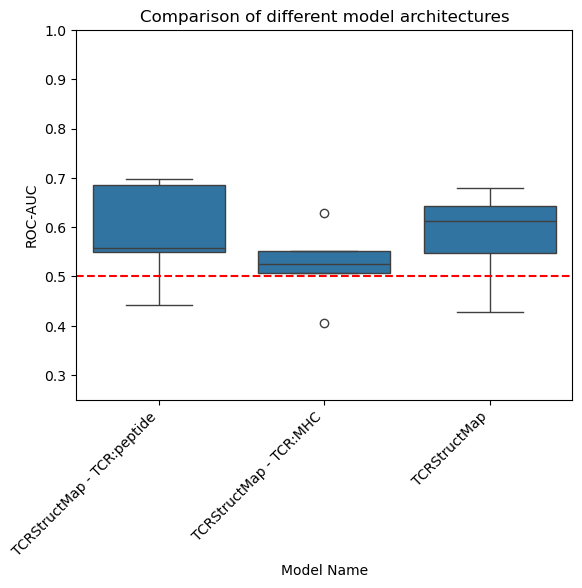

,mean,median,std
model_name,,,
TCRStructMap - TCR:peptide,0.585950,0.557011,0.106229
TCRStructMap - TCR:MHC,0.524195,0.526174,0.080625
TCRStructMap,0.582115,0.612001,0.098665


In [8]:
plt.title('Comparison of different model architectures')

sns.boxplot(
    roc_results,
    x='model_name',
    y='roc_auc',
    order=sorted(roc_results['model_name'].unique(), reverse=True),
)
plt.axhline(0.5, color='r', linestyle='dashed')

plt.ylabel('ROC-AUC')
plt.xlabel('Model Name')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.25, 1.0])
plt.show()

roc_results_agg = roc_results.groupby('model_name')['roc_auc'].agg(['mean', 'median', 'std'])
roc_results_agg = roc_results_agg.loc[sorted(roc_results_agg.index, reverse=True)]

roc_results_agg

In [9]:
pg.friedman(roc_results, dv='roc_auc', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.84,1.6,6.4,21.0,0.001936


In [10]:
groups = list(roc_results.set_index('fold').groupby('model_name')['roc_auc'])
groups = sorted(groups, reverse=True)
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap - TCR:peptide,TCRStructMap - TCR:MHC,0.0,0.0625,False
1,TCRStructMap - TCR:peptide,TCRStructMap,5.0,0.6250,False
2,TCRStructMap - TCR:MHC,TCRStructMap,0.0,0.0625,False


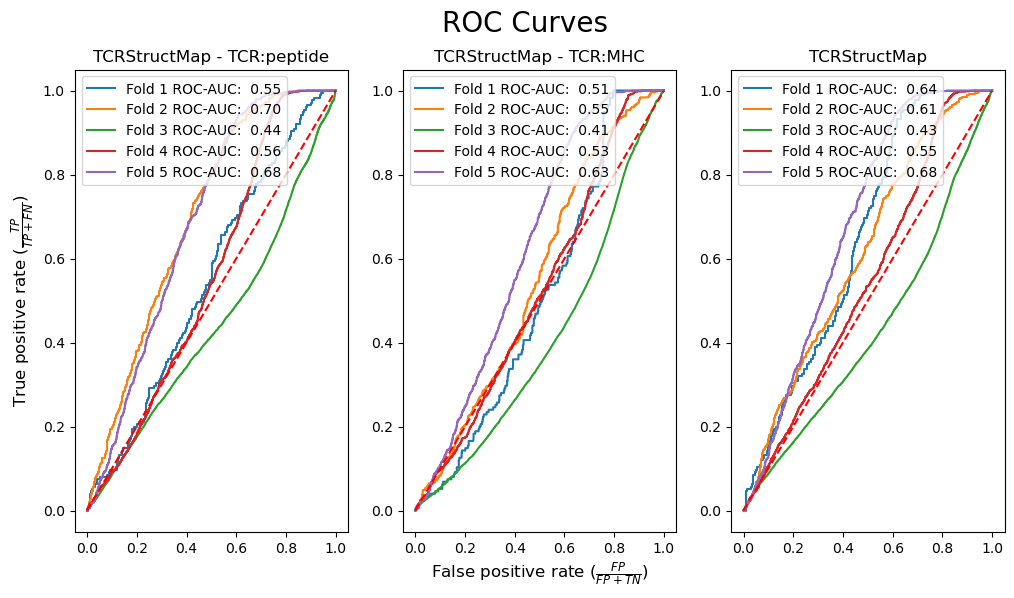

In [11]:
model_groups = roc_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('ROC Curves', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['roc_auc'].to_numpy()[0]
        group = fold_group.explode(['tpr', 'fpr'])

        axes[i].plot(group['fpr'], group['tpr'], label=f'Fold {fold} ROC-AUC: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)', fontsize=12)

    axes[i].set_title(model_name)

    axes[i].plot([0, 1], [0, 1], 'r--')
    axes[i].legend()

In [12]:
model_groups = roc_results.groupby('model_name')

fpr_interp = np.linspace(0, 1, 100)
tpr_interp = {}

for model_name, model_group in model_groups:
    tpr_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['tpr', 'fpr'])

        tpr_interp[model_name][fold] = np.interp(fpr_interp, group['fpr'].apply(float), group['tpr'].apply(float))

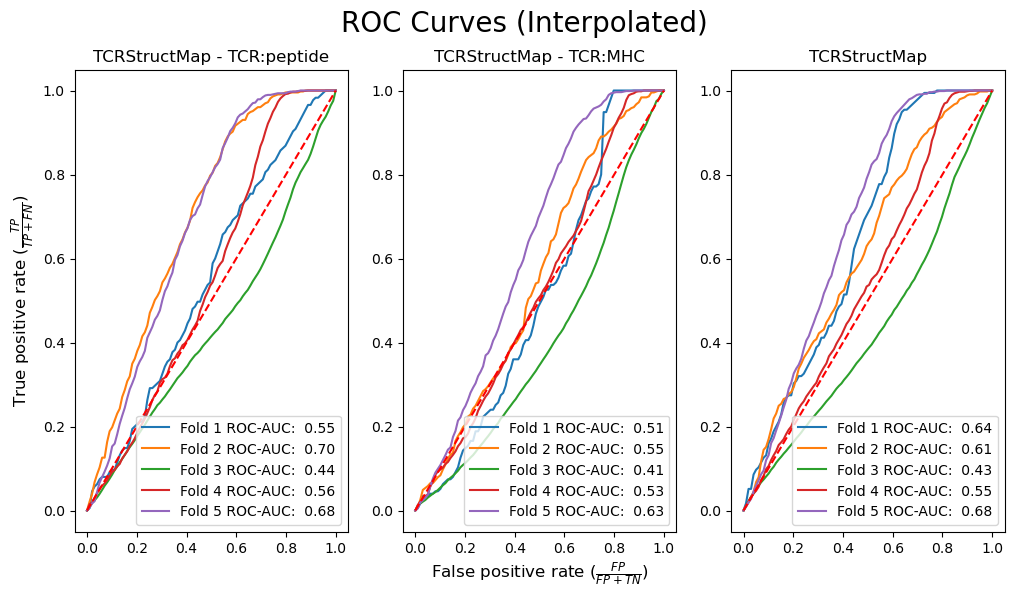

In [13]:
model_groups = roc_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('ROC Curves (Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['roc_auc'].to_numpy()[0]

        axes[i].plot(fpr_interp, tpr_interp[model_name][fold], label=f'Fold {fold} ROC-AUC: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0, 1], 'r--')
    axes[i].legend()

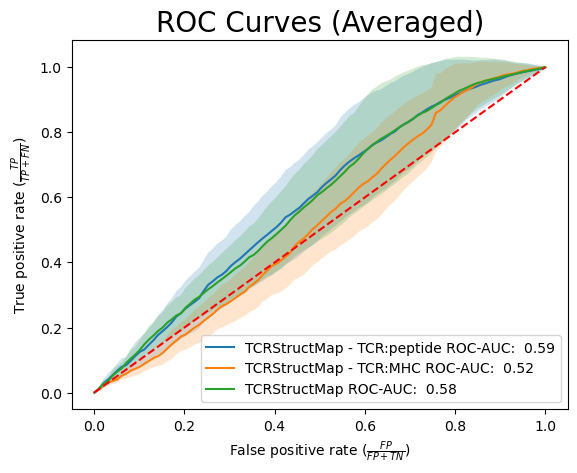

In [14]:
model_groups = roc_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

for model_name in model_group_names:
    model_group = model_groups.get_group(model_name)

    tpr_mean = np.mean(np.array(list(tpr_interp[model_name].values())).T, axis=1)
    tpr_std = np.std(np.array(list(tpr_interp[model_name].values())).T, axis=1)

    roc_auc = metrics.auc(fpr_interp, tpr_mean)

    plt.plot(fpr_interp, tpr_mean, label=f'{model_name} ROC-AUC: {roc_auc: .2f}')
    plt.fill_between(fpr_interp, tpr_mean - tpr_std, tpr_mean + tpr_std, alpha=0.2)

plt.title('ROC Curves (Averaged)', fontsize=20)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)')
plt.ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)')
plt.legend()

plt.show()

## Precision-Recall

In [15]:
pr_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results.name = 'pr_curve'
pr_results = pr_results.reset_index()

In [16]:
pr_results[['precision', 'recall', 'threshold']] = pr_results['pr_curve'].apply(pd.Series)

In [17]:
pr_results['pr_auc'] = pr_results.apply(lambda row: metrics.auc(row['recall'], row['precision']), axis=1)

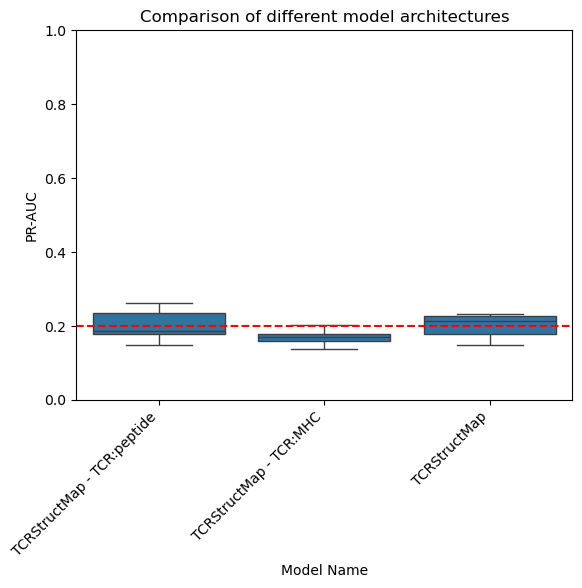

,mean,median,std
model_name,,,
TCRStructMap - TCR:peptide,0.201834,0.185860,0.045143
TCRStructMap - TCR:MHC,0.169025,0.169144,0.024808
TCRStructMap,0.199082,0.212683,0.035602


In [18]:
sns.boxplot(pr_results, x='model_name', y='pr_auc', order=sorted(pr_results['model_name'], reverse=True))
plt.axhline(0.2, color='r', linestyle='dashed')

plt.title('Comparison of different model architectures')
plt.ylim([0.0, 1.0])
plt.xlabel('Model Name')
plt.ylabel('PR-AUC')
plt.xticks(rotation=45, ha='right')
plt.show()

pr_results_agg = pr_results.groupby('model_name')['pr_auc'].agg(['mean', 'median', 'std'])
pr_results_agg = pr_results_agg.loc[sorted(pr_results_agg.index, reverse=True)]
pr_results_agg

In [19]:
pg.friedman(pr_results, dv='pr_auc', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.84,1.6,6.4,21.0,0.001936


In [20]:
groups = list(pr_results.set_index('fold').groupby('model_name')['pr_auc'])
groups = sorted(groups, reverse=True)
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap - TCR:peptide,TCRStructMap - TCR:MHC,0.0,0.0625,False
1,TCRStructMap - TCR:peptide,TCRStructMap,4.0,0.4375,False
2,TCRStructMap - TCR:MHC,TCRStructMap,0.0,0.0625,False


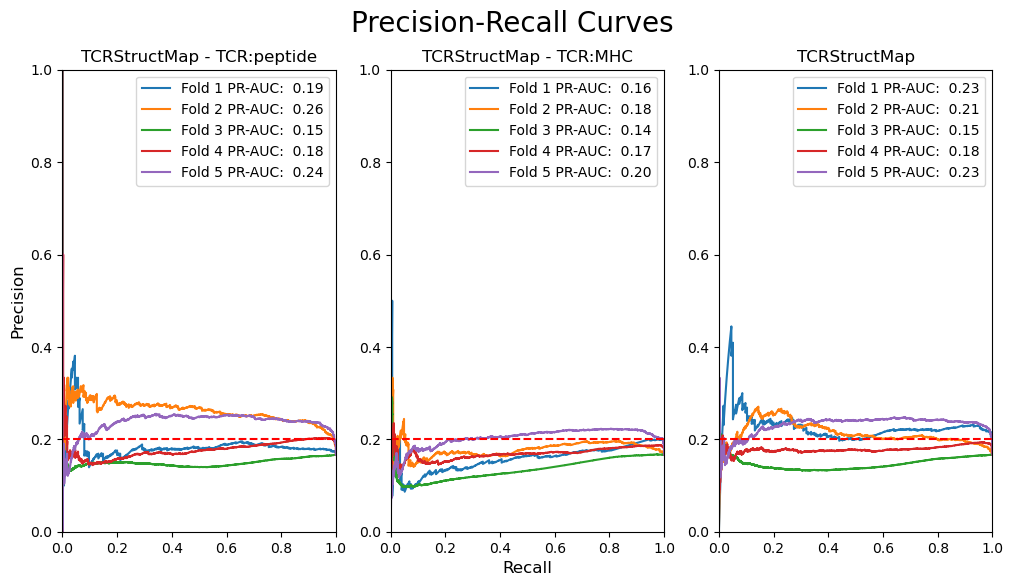

In [21]:
model_groups = pr_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]
        group = fold_group.explode(['recall', 'precision'])

        axes[i].plot(group['recall'], group['precision'], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [1 / 5, 1 / 5], 'r--')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend()

In [22]:
model_groups = pr_results.groupby('model_name')

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

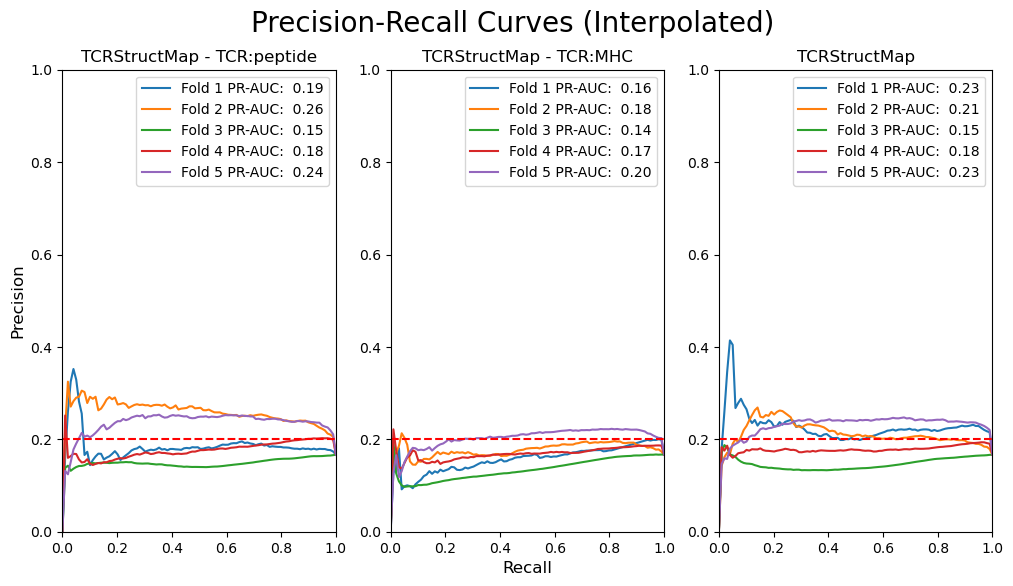

In [23]:
model_groups = pr_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves (Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]

        axes[i].plot(recall_interp, precision_interp[model_name][fold], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [1 / 5, 1 / 5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend()

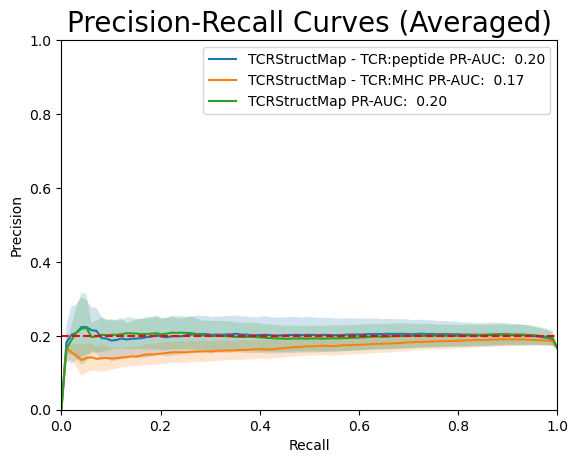

In [24]:
model_groups = pr_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

for model_name in model_group_names:
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.title('Precision-Recall Curves (Averaged)', fontsize=20)
plt.plot([0, 1], [1 / 5, 1 / 5], 'r--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.legend()

plt.show()

### Balancing classes

In [25]:
def down_sample_group(group: pd.DataFrame, random_state: int | np.random.Generator | None = None) -> pd.DataFrame:
    positives = group[group['label'] == 1]
    negatives = group[group['label'] == 0]

    num_positives = len(positives)
    num_negatives = len(negatives)

    if num_positives > num_negatives:
        return pd.concat([positives.sample(num_negatives, random_state=random_state), negatives])

    if num_positives < num_negatives:
        return pd.concat([positives, negatives.sample(num_positives, random_state=random_state)])

    return group


rng = np.random.default_rng(123)
balanced_predictions = (
    predictions.groupby(['model_name', 'fold'])
    .apply(
        down_sample_group,
        random_state=rng,
        include_groups=False,
    )
    .reset_index()
)

In [26]:
pr_results_balanced = balanced_predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results_balanced.name = 'pr_curve'
pr_results_balanced = pr_results_balanced.reset_index()

In [27]:
pr_results_balanced[['precision', 'recall', 'threshold']] = pr_results_balanced['pr_curve'].apply(pd.Series)

In [28]:
pr_results_balanced['pr_auc'] = pr_results_balanced.apply(
    lambda row: metrics.auc(row['recall'], row['precision']), axis=1
)

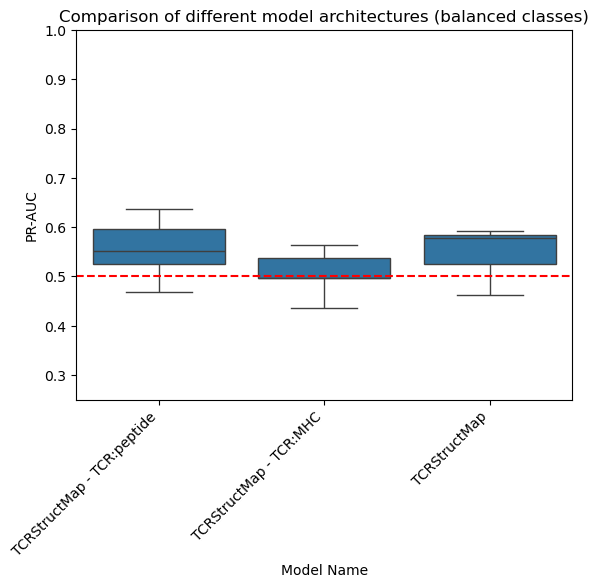

,mean,median,std
model_name,,,
TCRStructMap - TCR:peptide,0.555933,0.551905,0.064560
TCRStructMap - TCR:MHC,0.506451,0.497762,0.048640
TCRStructMap,0.548663,0.577737,0.054509


In [29]:
sns.boxplot(
    pr_results_balanced,
    x='model_name',
    y='pr_auc',
    order=sorted(pr_results_balanced['model_name'].unique(), reverse=True),
)
plt.axhline(0.5, color='r', linestyle='dashed')

plt.title('Comparison of different model architectures (balanced classes)')
plt.xlabel('Model Name')
plt.ylabel('PR-AUC')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.25, 1.0])
plt.show()

pr_results_balanced_agg = pr_results_balanced.groupby('model_name')['pr_auc'].agg(['mean', 'median', 'std'])
pr_results_balanced_agg = pr_results_balanced_agg.loc[sorted(pr_results_balanced_agg.index, reverse=True)]
pr_results_balanced_agg

In [30]:
pg.friedman(pr_results_balanced, dv='pr_auc', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.84,1.6,6.4,21.0,0.001936


In [31]:
groups = list(pr_results_balanced.set_index('fold').groupby('model_name')['pr_auc'])
groups = sorted(groups, reverse=True)
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap - TCR:peptide,TCRStructMap - TCR:MHC,0.0,0.0625,False
1,TCRStructMap - TCR:peptide,TCRStructMap,4.0,0.4375,False
2,TCRStructMap - TCR:MHC,TCRStructMap,0.0,0.0625,False


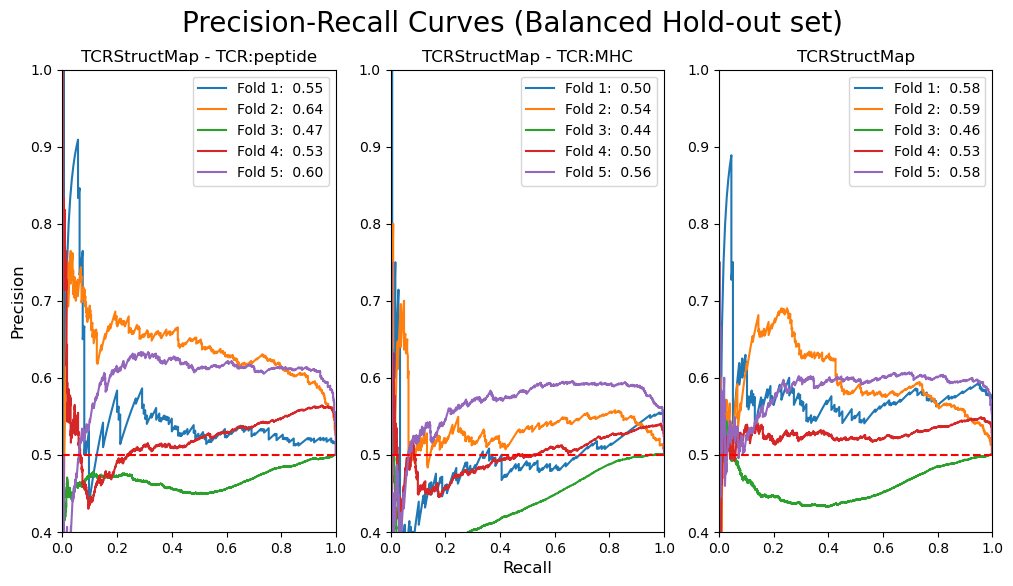

In [32]:
model_groups = pr_results_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves (Balanced Hold-out set)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['pr_auc'].to_numpy()[0]
        group = fold_group.explode(['recall', 'precision'])

        axes[i].plot(group['recall'], group['precision'], label=f'Fold {fold}: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0.5, 0.5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0.4, 1])
    axes[i].legend()

In [33]:
model_groups = pr_results_balanced.groupby('model_name')

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

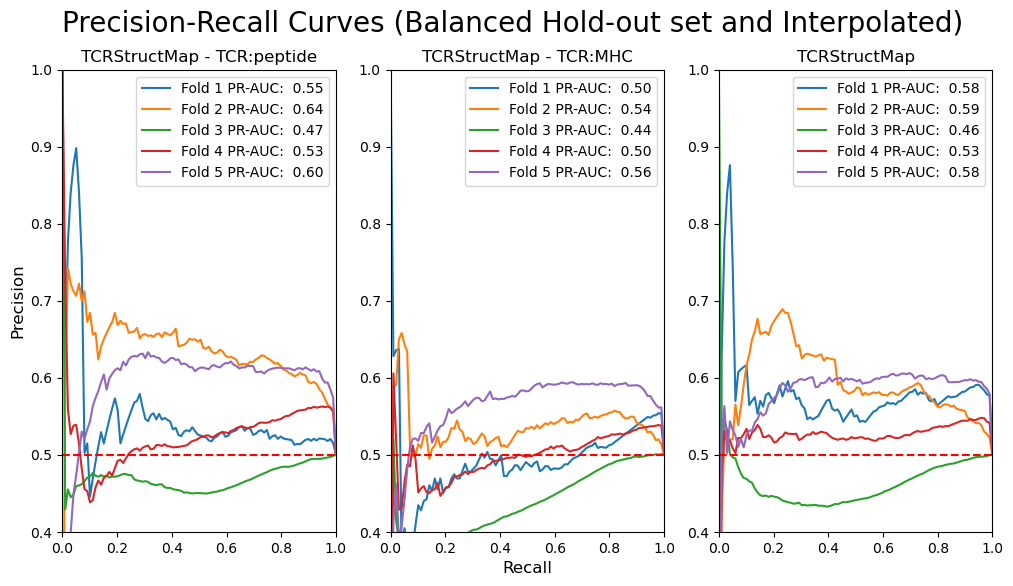

In [34]:
model_groups = pr_results_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves (Balanced Hold-out set and Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]

        axes[i].plot(recall_interp, precision_interp[model_name][fold], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0.5, 0.5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0.4, 1])
    axes[i].legend()

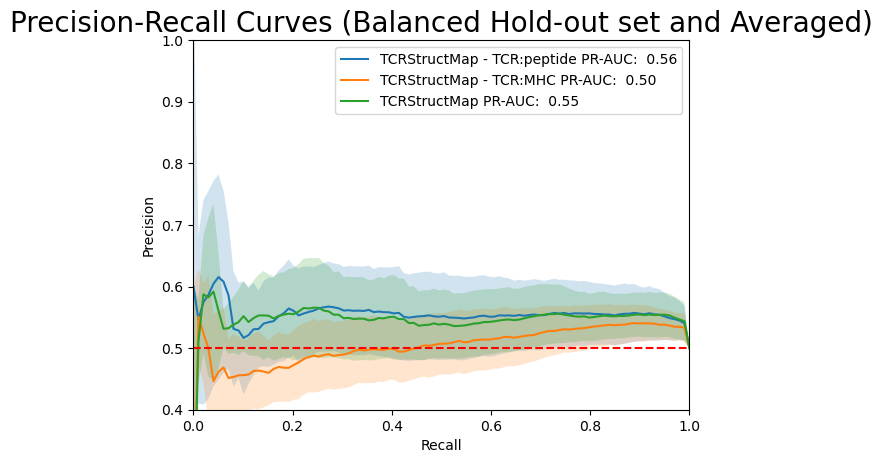

In [35]:
model_groups = pr_results_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

for model_name in model_group_names:
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.title('Precision-Recall Curves (Balanced Hold-out set and Averaged)', fontsize=20)
plt.plot([0, 1], [0.5, 0.5], 'r--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0.4, 1])
plt.legend()

plt.show()

## F1-Score

In [36]:
THRESHOLD = 0.5
predictions['prediction_binary'] = (predictions['prediction'] > THRESHOLD).apply(int)

In [37]:
f1_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results.name = 'f1_score'
f1_results = f1_results.reset_index()

f1_results_table = f1_results.pivot_table(index='fold', columns='model_name', values='f1_score')
f1_results_table = f1_results_table[sorted(f1_results_table.columns, reverse=True)]
f1_results_table

model_name,TCRStructMap - TCR:peptide,TCRStructMap - TCR:MHC,TCRStructMap
fold,,,
1,0.095238,0.000000,0.166667
2,0.077236,0.025532,0.190337
3,0.065643,0.085030,0.126461
4,0.061303,0.060914,0.097100
5,0.107632,0.007595,0.149454


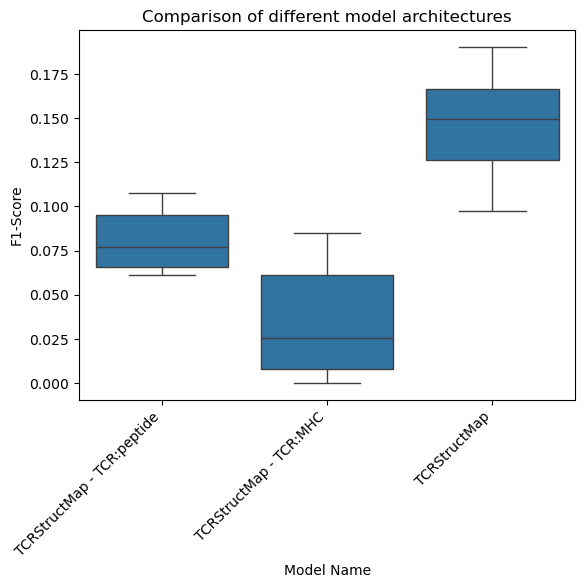

,mean,median,std
model_name,,,
TCRStructMap - TCR:peptide,0.081410,0.077236,0.019680
TCRStructMap - TCR:MHC,0.035814,0.025532,0.036183
TCRStructMap,0.146004,0.149454,0.035978


In [38]:
sns.boxplot(
    f1_results,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results['model_name'].unique(), reverse=True),
)

plt.title('Comparison of different model architectures')
plt.xlabel('Model Name')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.show()

f1_results_agg = f1_results.groupby('model_name')['f1_score'].agg(['mean', 'median', 'std'])
f1_results_agg = f1_results_agg.loc[sorted(f1_results_agg.index, reverse=True)]
f1_results_agg

In [39]:
pg.friedman(f1_results, dv='f1_score', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.84,1.6,6.4,21.0,0.001936


In [40]:
groups = list(f1_results.set_index('fold').groupby('model_name')['f1_score'])
groups = sorted(groups, reverse=True)
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap - TCR:peptide,TCRStructMap - TCR:MHC,2.0,0.1875,False
1,TCRStructMap - TCR:peptide,TCRStructMap,0.0,0.0625,False
2,TCRStructMap - TCR:MHC,TCRStructMap,0.0,0.0625,False


### Balancing classes

In [41]:
balanced_predictions['prediction_binary'] = (balanced_predictions['prediction'] > THRESHOLD).apply(int)

In [42]:
f1_results_balanced = balanced_predictions.groupby(['model_name', 'fold']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results_balanced.name = 'f1_score'
f1_results_balanced = f1_results_balanced.reset_index()

f1_results_balanced_table = f1_results_balanced.pivot_table(index='fold', columns='model_name', values='f1_score')
f1_results_balanced_table = f1_results_balanced_table[sorted(f1_results_balanced_table.columns, reverse=True)]
f1_results_balanced_table

model_name,TCRStructMap - TCR:peptide,TCRStructMap - TCR:MHC,TCRStructMap
fold,,,
1,0.107527,0.000000,0.211982
2,0.083516,0.027273,0.246212
3,0.078618,0.122887,0.178989
4,0.070175,0.072227,0.119701
5,0.126582,0.007792,0.190782


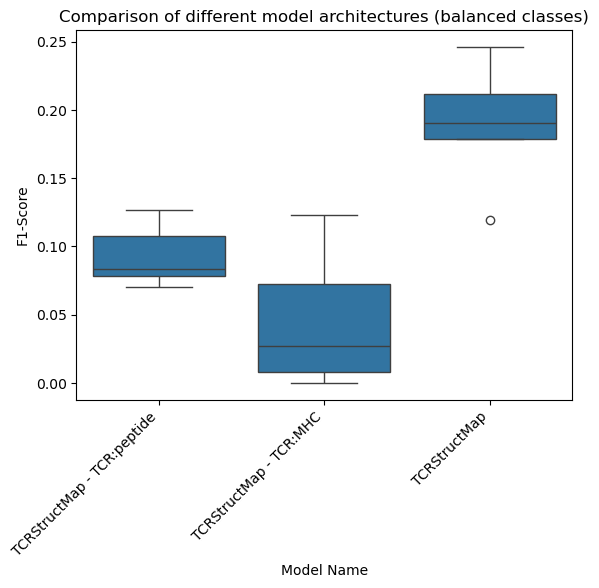

,mean,median,std
model_name,,,
TCRStructMap - TCR:peptide,0.093284,0.083516,0.023217
TCRStructMap - TCR:MHC,0.046036,0.027273,0.051298
TCRStructMap,0.189533,0.190782,0.046652


In [43]:
sns.boxplot(
    f1_results_balanced,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results_balanced['model_name'].unique(), reverse=True),
)

plt.title('Comparison of different model architectures (balanced classes)')
plt.xlabel('Model Name')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.show()

f1_results_balanced_agg = f1_results_balanced.groupby('model_name')['f1_score'].agg(['mean', 'median', 'std'])
f1_results_balanced_agg = f1_results_balanced_agg.loc[sorted(f1_results_balanced_agg.index, reverse=True)]
f1_results_balanced_agg

In [44]:
pg.friedman(f1_results_balanced, dv='f1_score', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.76,1.6,6.4,12.666667,0.007191


In [45]:
groups = list(f1_results_balanced.set_index('fold').groupby('model_name')['f1_score'])
groups = sorted(groups, reverse=True)
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap - TCR:peptide,TCRStructMap - TCR:MHC,3.0,0.3125,False
1,TCRStructMap - TCR:peptide,TCRStructMap,0.0,0.0625,False
2,TCRStructMap - TCR:MHC,TCRStructMap,0.0,0.0625,False


## Comparison of prediction results to mimimum distance between the peptides and the training set

In [46]:
sequences = pd.read_csv('data/interim/sequences_pMHC_split.csv', index_col='index')

In [47]:
predictions = predictions.merge(sequences[['peptide']], how='left', left_on='index', right_index=True)

In [48]:
with open('data/interim/peptides.txt') as fh:
    peptide_key = np.array(fh.read().rstrip().split('\n'))

peptide_distances = np.loadtxt('data/interim/peptide_distances.txt', dtype=int)

In [49]:
def get_minimum_peptide_distance(peptide_sequence: str, training_peptides: np.ndarray) -> int:
    if peptide_sequence not in peptide_key:
        return np.nan

    training_key_idxs = np.where(np.isin(peptide_key, training_peptides))[0]
    peptide_index = np.where(peptide_sequence == peptide_key)[0][0]

    return np.min(peptide_distances[peptide_index][training_key_idxs])

In [50]:
peptide_folds = predictions[['peptide', 'fold', 'model_name']].drop_duplicates()
peptide_folds['min_peptide_distance'] = peptide_folds.apply(
    lambda row: get_minimum_peptide_distance(row.peptide, sequences[sequences['fold'] != row.fold]['peptide'].unique()),
    axis=1,
)

In [51]:
predictions = predictions.merge(peptide_folds, how='left', on=['peptide', 'fold', 'model_name'])

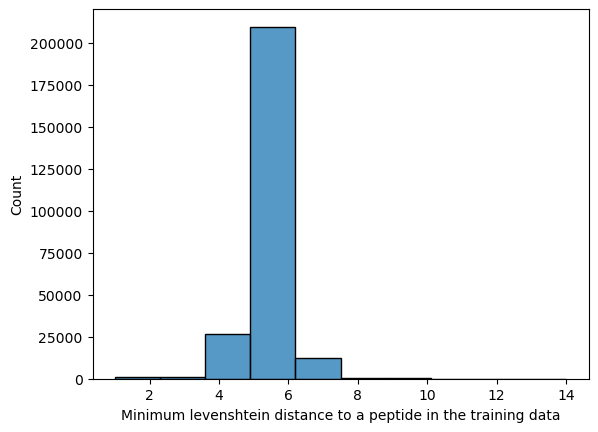

In [52]:
sns.histplot(predictions, x='min_peptide_distance', bins=10)

plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.show()

In [53]:
peptide_distance_roc_aucs = predictions.groupby(['model_name', 'fold', 'min_peptide_distance']).apply(
    lambda group: metrics.roc_auc_score(group['label'], group['prediction']),
    include_groups=False,
)
peptide_distance_roc_aucs.name = 'roc_auc'

peptide_distance_roc_aucs = peptide_distance_roc_aucs.reset_index()

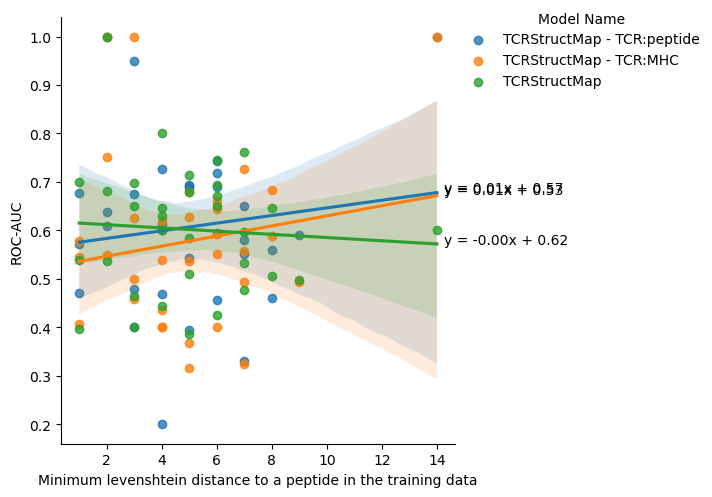

In [54]:
ax = sns.lmplot(
    peptide_distance_roc_aucs,
    x='min_peptide_distance',
    y='roc_auc',
    hue='model_name',
    hue_order=sorted(peptide_distance_roc_aucs['model_name'].unique(), reverse=True),
)

for model_name in peptide_distance_roc_aucs['model_name'].unique():
    subset = peptide_distance_roc_aucs[peptide_distance_roc_aucs['model_name'] == model_name]
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['min_peptide_distance'], subset['roc_auc'])

    equation = f'y = {slope:.2f}x + {intercept:.2f}'

    x_pos = subset['min_peptide_distance'].max() + 0.25
    y_pos = slope * x_pos + intercept

    plt.text(x_pos, y_pos, equation, color='black')

ax.legend.set_title('Model Name')
ax.legend.set_loc('upper right')

plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.ylabel('ROC-AUC')

plt.show()

In [55]:
peptide_distance_roc_aucs_lines = peptide_distance_roc_aucs.groupby(['model_name', 'fold']).apply(
    lambda group: stats.linregress(group['min_peptide_distance'], group['roc_auc']),
    include_groups=False,
)

peptide_distance_roc_aucs_lines.name = 'line'
peptide_distance_roc_aucs_lines = peptide_distance_roc_aucs_lines.reset_index()

peptide_distance_roc_aucs_lines[['slope', 'intercept', 'r_value', 'p_value', 'std_err']] = (
    peptide_distance_roc_aucs_lines['line'].apply(pd.Series)
)

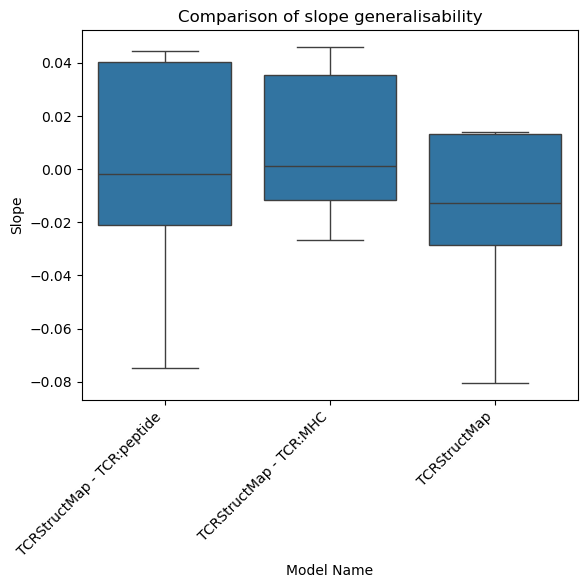

,mean,median,std
model_name,,,
TCRStructMap - TCR:peptide,-0.002705,-0.002059,0.048902
TCRStructMap - TCR:MHC,0.008863,0.001096,0.030869
TCRStructMap,-0.018875,-0.012713,0.038882


In [56]:
sns.boxplot(
    peptide_distance_roc_aucs_lines,
    x='model_name',
    y='slope',
    order=sorted(peptide_distance_roc_aucs_lines['model_name'].unique(), reverse=True),
)

plt.title('Comparison of slope generalisability')
plt.ylabel('Slope')
plt.xlabel('Model Name')
plt.xticks(rotation=45, ha='right')
plt.show()

peptide_distance_roc_aucs_lines_agg = peptide_distance_roc_aucs_lines.groupby('model_name')['slope'].agg(
    ['mean', 'median', 'std'],
)
peptide_distance_roc_aucs_lines_agg = peptide_distance_roc_aucs_lines_agg.loc[
    sorted(peptide_distance_roc_aucs_lines_agg.index, reverse=True)
]
peptide_distance_roc_aucs_lines_agg

In [57]:
pg.friedman(peptide_distance_roc_aucs_lines, dv='slope', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.52,1.6,6.4,4.333333,0.069651


In [58]:
groups = list(peptide_distance_roc_aucs_lines.set_index('fold').groupby('model_name')['slope'])
groups = sorted(groups, reverse=True)
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap - TCR:peptide,TCRStructMap - TCR:MHC,5.0,0.6250,False
1,TCRStructMap - TCR:peptide,TCRStructMap,4.0,0.4375,False
2,TCRStructMap - TCR:MHC,TCRStructMap,0.0,0.0625,False
